In [1]:
from pathlib import Path
import numpy as np
import finitewave as fw


path = Path("/Users/arstanbekokenov/Projects/Finitewave/examples/data/atrial_mesh")

points = np.load(path / "coarse_points.npy") / 1000
elems = np.load(path / "coarse_elems.npy")


tissue = fw.CardiacTissueElements(points, elems, elem_type=fw.ElementType.TRIANGLE)
tissue.conductivity = 2.

spatial_discretization = fw.FiniteElementDiscretization()
K, M = spatial_discretization.compute_weights(tissue)

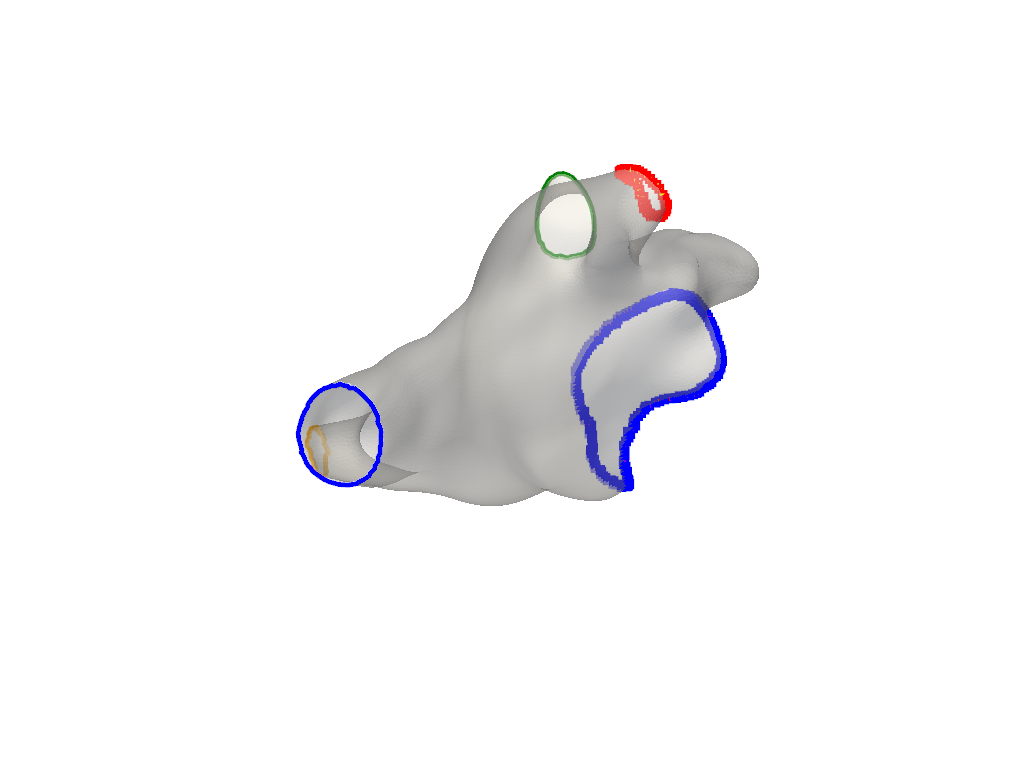

In [10]:
import pyvista as pv

poly = pv.PolyData(points, np.hstack((np.full((elems.shape[0], 1), 3), elems)).astype(np.int64))

#extract boundary edges
edges = poly.extract_feature_edges(boundary_edges=True, feature_edges=False, manifold_edges=False, non_manifold_edges=False)

# separate the edges into connected lines
lines = edges.connectivity()

groups = lines["RegionId"]
grouped_lines = [lines.extract_cells(groups == i) for i in np.unique(groups)]
grouped_lines = sorted(grouped_lines, key=lambda x: x.n_points, reverse=True)
grouped_colors = ["red", "green", "blue", "yellow", "orange", "purple", "cyan", "magenta"]

s1_points = grouped_lines[3].points
s2_points = grouped_lines[0].points


import numpy as np
from scipy.spatial import cKDTree

def closest_points(points_a, points_b):
    points_a = np.asarray(points_a)
    points_b = np.asarray(points_b)

    distances, indices_b = cKDTree(points_b).query(points_a)
    index_a = np.argmin(distances)
    index_b = indices_b[index_a]

    return points_a[index_a], points_b[index_b]

# s1_closest, s2_closest = closest_points(s1_points, s2_points)

pv.set_jupyter_backend("static")
pl = pv.Plotter()
pl.add_mesh(poly, color="white", opacity=0.5)
for i, line in enumerate(grouped_lines):
    pl.add_mesh(line, color=grouped_colors[i], line_width=5)
    pl.add_points(s1_points, color="red", point_size=10)
    pl.add_points(s2_points, color="blue", point_size=10)
pl.show()
# longest_line = max(lines.split_bodies(), key=lambda x: x.n_points)


In [11]:

stim_prepacing = fw.StimSingleCell(dt=0.005)
stim_prepacing.add_stim(n_beats=30, cycle_length=1000., curr_value=20., duration=2.)
stim_prepacing.add_stim(n_beats=30, cycle_length=500., curr_value=20., duration=2.)
stim_prepacing.add_stim(n_beats=30, cycle_length=300., curr_value=20., duration=2.)

cardiac_model = fw.Courtemanche()
cardiac_model.prepacing(stim_prepacing)

stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimCurrentElectrodes(0, 100, 0.5, s1_points, size=2))
stim_sequence.add_stim(fw.StimCurrentElectrodes(400, 200, 1.0, s2_points, size=5))   

# create model object and set up parameters:
simulation = fw.CardiacSimulation(backend="jax")
simulation.dt = 0.01
simulation.t_max = 400
# add the tissue and the stim parameters to the model object:
simulation.cardiac_tissue = tissue
simulation.cardiac_model = cardiac_model
simulation.stim_sequence = stim_sequence
# set up time integration:
simulation.time_integration = fw.BackwardEulerTimeIntegration(atol=1e-8, maxiter=100)

# run the model:
simulation.run()

# get the resulting potential at the element centers:
u = simulation.cardiac_model.output("u")

Running Courtemanche on Triangle Elements: 100%|██████████| 40000/40000 [01:18<00:00, 511.54it/s]


In [15]:
stim_sequence.add_stim(fw.StimCurrentElectrodes(410, 300, 1.0, s2_points, size=10)) 
simulation.t_max = 411
simulation.stim_sequence.initialize(simulation)
simulation.run(initialize=False)

Running Courtemanche on Triangle Elements: 100%|██████████| 1000/1000 [00:01<00:00, 615.17it/s]


In [16]:
pv.set_jupyter_backend("trame")
atrial_grid = fw.PyVistaSurfaceGrid(points, elems)
atrial_grid["u"] = u

pl = pv.Plotter()
pl.add_mesh(atrial_grid, scalars="u", cmap="jet")
pl.add_points(s1_points, color="blue", point_size=10)
# pl.add_points(s2_points, color="red", point_size=10)
pl.show()

Widget(value='<iframe src="http://localhost:54181/index.html?ui=P_0x3a8b147d0_8&reconnect=auto" class="pyvista…

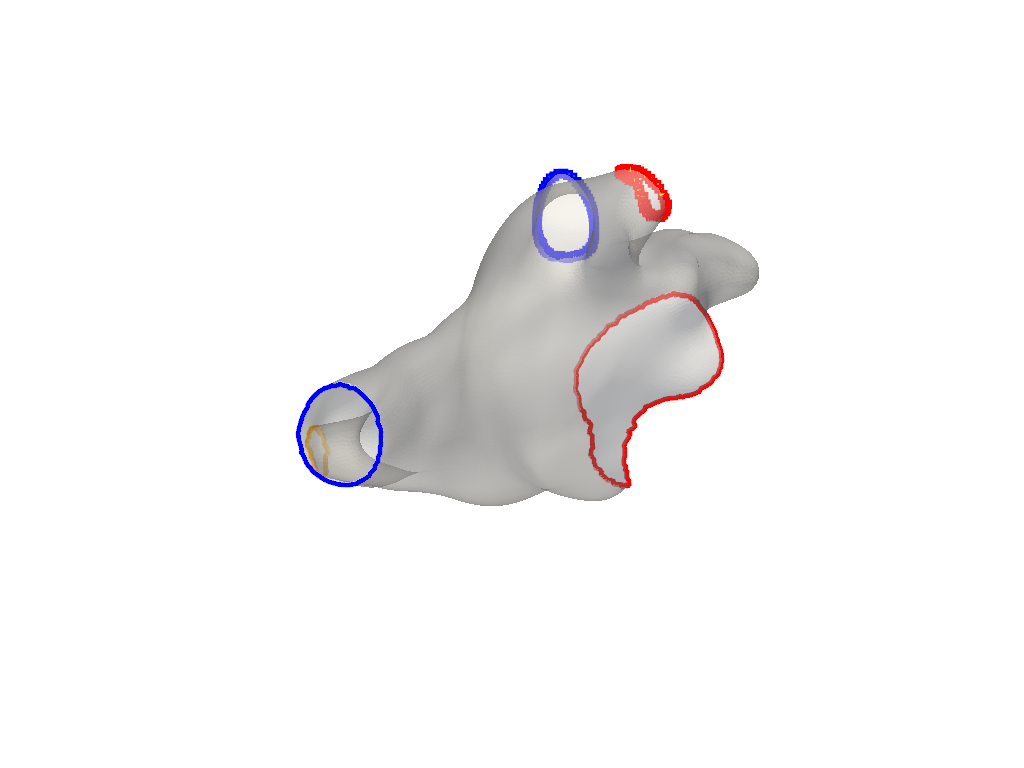

In [48]:
import pyvista as pv

poly = pv.PolyData(points, np.hstack((np.full((elems.shape[0], 1), 3), elems)).astype(np.int64))

#extract boundary edges
edges = poly.extract_feature_edges(boundary_edges=True, feature_edges=False, manifold_edges=False, non_manifold_edges=False)

# separate the edges into connected lines
lines = edges.connectivity()

groups = lines["RegionId"]
grouped_lines = [lines.extract_cells(groups == i) for i in np.unique(groups)]
grouped_lines = sorted(grouped_lines, key=lambda x: x.n_points, reverse=True)
grouped_colors = ["red", "green", "blue", "yellow", "orange", "purple", "cyan", "magenta"]

s1_points = grouped_lines[3].points
s2_points = grouped_lines[1].points

pv.set_jupyter_backend("static")
pl = pv.Plotter()
pl.add_mesh(poly, color="white", opacity=0.5)
for i, line in enumerate(grouped_lines):
    pl.add_mesh(line, color=grouped_colors[i], line_width=5)
    pl.add_points(s1_points, color="red", point_size=10)
    pl.add_points(s2_points, color="blue", point_size=10)
pl.show()
# longest_line = max(lines.split_bodies(), key=lambda x: x.n_points)
